# HW5 — SVD, Structure, and Recommendations

This notebook contains solutions and scaffolding code for:

- **HW5-1:** Create a 100×100 matrix with strong local adjacency correlation, compute its SVD, and measure how much Frobenius norm energy is captured by the top singular vectors. Repeat with an independent random matrix.
- **HW5-2:** Download and process the **MovieLens 100k** dataset (100,000 ratings, 943 users, 1682 movies), compute an SVD of the user–movie matrix, and discuss how to interpret singular vectors to reveal structure and enable recommendations.

> Tips:
> - Run each section in order.
> - If the MovieLens download fails (e.g., offline), you can manually place the dataset folder next to this notebook and set `DATA_DIR` accordingly.


## Setup
We use only standard scientific Python libraries. If you are running this in a new environment, make sure you have `numpy`, `matplotlib`, and `pandas` installed.

In [8]:
import os
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

# Ensure reproducibility where appropriate
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)


---
## HW5-1 — Correlated vs. Independent Random Matrices

### Goal
1. Create a **100×100** matrix `A_corr` with strong **adjacency correlation** (each entry correlated with its neighbors).
2. Compute the SVD and measure what fraction of the Frobenius norm is captured by the top **k = 10** singular values.
3. Find the **minimum k** such that **≥ 95%** of the Frobenius norm is captured.
4. Repeat steps 2–3 for an **independent** random matrix `A_iid` with entries i.i.d. `Uniform(0,1)`.

### How we induce adjacency correlation
We start with i.i.d. noise and apply a **local averaging filter** (a small 2D kernel) repeatedly. This acts like a blur/smoothing operator, making each entry a local average of its neighbors—hence strong correlation.


In [9]:
def local_average_correlated_matrix(n: int = 100, kernel_radius: int = 1, passes: int = 3, seed: int = 42) -> np.ndarray:
    """Create an n×n matrix with strong local adjacency correlation by
    repeatedly applying a simple (2*kernel_radius+1)^2 averaging filter.

    Args:
        n: size of the square matrix
        kernel_radius: neighborhood radius (1 → 3×3 kernel; 2 → 5×5 kernel, etc.)
        passes: number of smoothing passes to amplify correlation
        seed: RNG seed for reproducibility
    Returns:
        A correlated matrix with entries roughly in [0,1].
    """
    rng_local = np.random.default_rng(seed)
    A = rng_local.random((n, n))  # start with Uniform(0,1)
    k = kernel_radius
    size = 2 * k + 1
    # Implement a fast box blur using cumulative sums (integral image)
    def box_blur(img: np.ndarray, r: int) -> np.ndarray:
        # Pad with edge values to reduce border artifacts
        padded = np.pad(img, pad_width=r, mode='edge')
        csum = padded.cumsum(axis=0).cumsum(axis=1)
        # Compute sum over each (size×size) window via inclusion–exclusion
        H, W = img.shape
        out = (
            csum[2*r:2*r+H, 2*r:2*r+W]
            - csum[0:H, 2*r:2*r+W]
            - csum[2*r:2*r+H, 0:W]
            + csum[0:H, 0:W]
        ) / (size * size)
        return out

    for _ in range(passes):
        A = box_blur(A, k)
    # Normalize back to [0,1]
    A = (A - A.min()) / (A.max() - A.min() + 1e-12)
    return A

def svd_energy_fractions(A: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return singular values and cumulative energy fractions of A.
    Energy is measured as fraction of Frobenius norm captured by top-k singular values.
    """
    # full_matrices=False gives economical SVD; singular values in descending order
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    energy = (s ** 2)
    cum = np.cumsum(energy)
    total = energy.sum()
    fractions = cum / total
    return s, fractions

def k_for_threshold(fractions: np.ndarray, threshold: float = 0.95) -> int:
    """Smallest k such that fractions[k-1] >= threshold."""
    idx = np.searchsorted(fractions, threshold, side='left')
    return int(idx + 1)

# Generate correlated and independent matrices
A_corr = local_average_correlated_matrix(n=100, kernel_radius=2, passes=4, seed=42)
A_iid = rng.random((100, 100))

# Compute SVD energy capture
s_corr, frac_corr = svd_energy_fractions(A_corr)
s_iid, frac_iid = svd_energy_fractions(A_iid)

top10_corr = frac_corr[9]  # fraction captured by top-10 singular values
top10_iid = frac_iid[9]

k95_corr = k_for_threshold(frac_corr, 0.95)
k95_iid = k_for_threshold(frac_iid, 0.95)

print(f"Correlated matrix: top-10 capture = {top10_corr:.4f}, k for 95% = {k95_corr}")
print(f"IID matrix:        top-10 capture = {top10_iid:.4f}, k for 95% = {k95_iid}")


Correlated matrix: top-10 capture = 0.9932, k for 95% = 3
IID matrix:        top-10 capture = 0.8250, k for 95% = 40


### Visualize singular values and cumulative energy
We plot the singular values and the cumulative fraction of Frobenius norm captured.

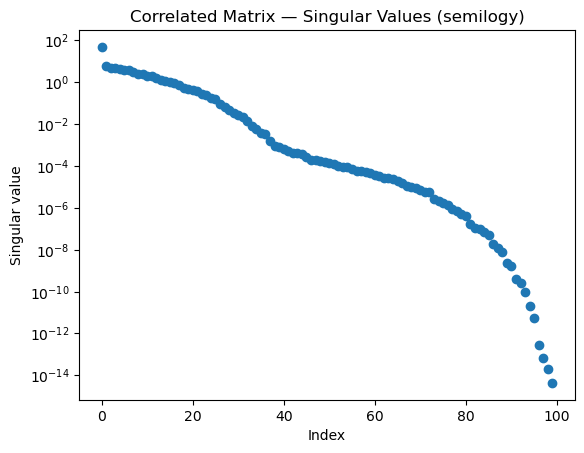

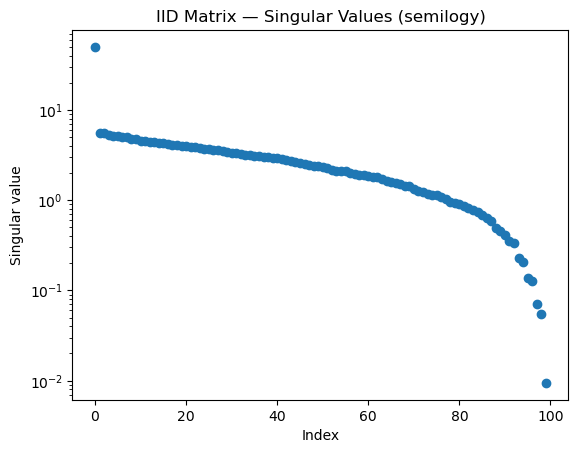

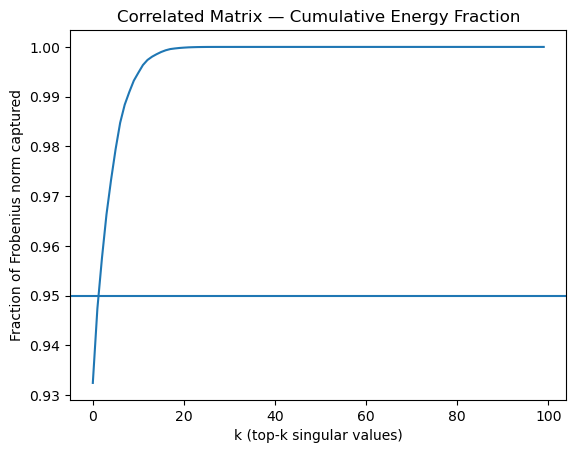

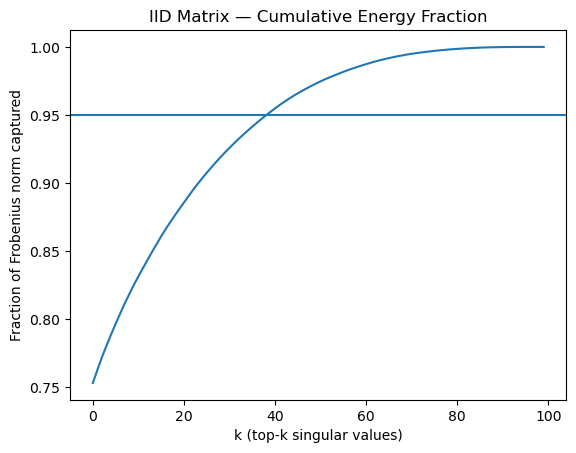

In [10]:
# Plot singular values
plt.figure()
plt.semilogy(s_corr, marker='o', linestyle='None')
plt.title('Correlated Matrix — Singular Values (semilogy)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.show()

plt.figure()
plt.semilogy(s_iid, marker='o', linestyle='None')
plt.title('IID Matrix — Singular Values (semilogy)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.show()

# Plot cumulative energy fractions
plt.figure()
plt.plot(frac_corr)
plt.axhline(0.95)
plt.title('Correlated Matrix — Cumulative Energy Fraction')
plt.xlabel('k (top-k singular values)')
plt.ylabel('Fraction of Frobenius norm captured')
plt.show()

plt.figure()
plt.plot(frac_iid)
plt.axhline(0.95)
plt.title('IID Matrix — Cumulative Energy Fraction')
plt.xlabel('k (top-k singular values)')
plt.ylabel('Fraction of Frobenius norm captured')
plt.show()


---
## HW5-2 — Finding Structure in Movie Ratings (MovieLens 100k)

**Dataset:** https://grouplens.org/datasets/movielens/100k/

- `m = 1682` movies
- `n = 943` users
- `100,000` total ratings

### High-level plan
1. **Download & unpack** the MovieLens 100k dataset.
2. **Build the ratings matrix** `R` of shape (movies × users). Ratings are 1–5; missing entries are 0.
3. **Mean-center** by user (subtract each user's mean from their rated entries) to reduce user bias.
4. **Compute SVD** of the centered matrix.
5. **Interpretation:**
   - Left singular vectors (columns of `U`) ≈ **stereotypical movies/themes**.
   - Right singular vectors (columns of `V`) ≈ **stereotypical viewers**.
6. **Energy & rank-k approximation:** use top-k singular vectors to reconstruct and discuss recommendation potential.


In [11]:
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
DATA_DIR = "ml-100k"

def download_and_extract_ml100k(url: str = DATA_URL, dest_dir: str = DATA_DIR) -> None:
    if os.path.isdir(dest_dir):
        print(f"Dataset already present at '{dest_dir}'. Skipping download.")
        return
    print("Downloading MovieLens 100k…")
    with urllib.request.urlopen(url) as resp:
        data = resp.read()
    print("Extracting…")
    with zipfile.ZipFile(io.BytesIO(data)) as zf:
        zf.extractall('.')
    print("Done.")

download_and_extract_ml100k()

u_data_path = os.path.join(DATA_DIR, "u.data")  # user\titem\trating\ttimestamp
u_item_path = os.path.join(DATA_DIR, "u.item")  # movie metadata

cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings_df = pd.read_csv(u_data_path, sep='\t', names=cols, engine='python')
print(ratings_df.head())
n_users = ratings_df['user_id'].max()
n_movies = ratings_df['movie_id'].max()
print(f"Users: {n_users}, Movies: {n_movies}")

# Build ratings matrix R (movies × users)
R = np.zeros((n_movies, n_users), dtype=np.float64)
for row in ratings_df.itertuples(index=False):
    R[row.movie_id - 1, row.user_id - 1] = row.rating

print(f"R shape: {R.shape}")

# Mean-center by user (only over rated entries); keep zeros for missing
user_means = np.divide(
    R.sum(axis=0),
    (R != 0).sum(axis=0),
    out=np.zeros(R.shape[1], dtype=float),
    where=(R != 0).sum(axis=0) != 0
)

R_centered = R.copy()
for j in range(R.shape[1]):
    mask = R[:, j] != 0
    R_centered[mask, j] = R[mask, j] - user_means[j]

# SVD (economical)
U, s, Vt = np.linalg.svd(R_centered, full_matrices=False)
energy = s**2
cum_energy = np.cumsum(energy) / energy.sum()

print(f"Top-10 energy fraction: {cum_energy[9]:.4f}")
k95 = int(np.searchsorted(cum_energy, 0.95) + 1)
print(f"k for 95% energy: {k95}")


Dataset already present at 'ml-100k'. Skipping download.
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
Users: 943, Movies: 1682
R shape: (1682, 943)
Top-10 energy fraction: 0.1743
k for 95% energy: 416


### Visualize singular spectrum and cumulative energy (MovieLens 100k)

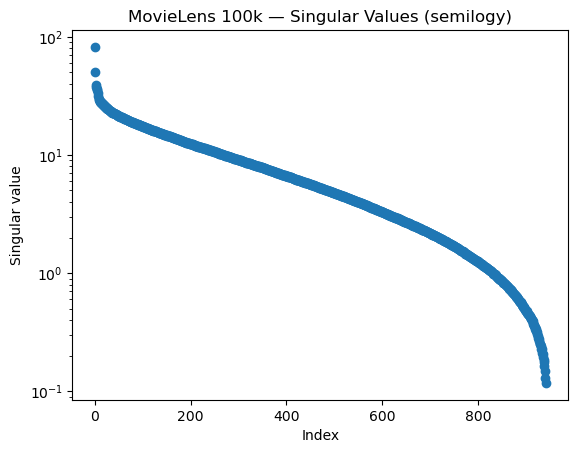

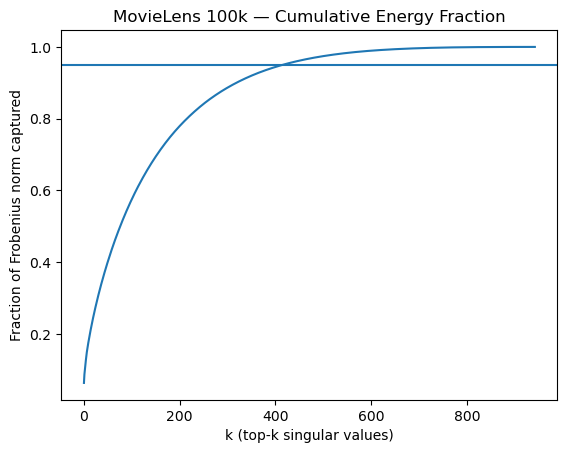

In [12]:
plt.figure()
plt.semilogy(s, marker='o', linestyle='None')
plt.title('MovieLens 100k — Singular Values (semilogy)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.show()

plt.figure()
plt.plot(cum_energy)
plt.axhline(0.95)
plt.title('MovieLens 100k — Cumulative Energy Fraction')
plt.xlabel('k (top-k singular values)')
plt.ylabel('Fraction of Frobenius norm captured')
plt.show()


### Interpreting singular vectors
- **Left singular vectors (`U`)** span stereotypical **movie themes**. A movie's row in `R_centered` can be expressed as a combination of these themes.
- **Right singular vectors (`V`)** span stereotypical **viewer types**. A viewer's column in `R_centered` can be expressed as a combination of these viewer archetypes.

Below, we inspect the top components and show how to create a **rank-k approximation** that captures the main structure for recommendations.

Relative Frobenius error for rank-20: 0.8696


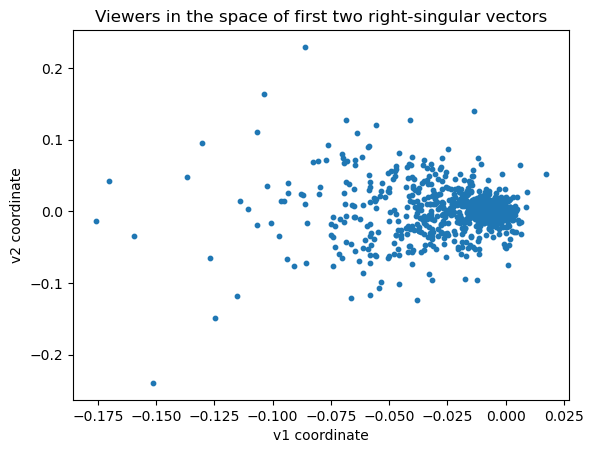

In [13]:
def rank_k_approx(U: np.ndarray, s: np.ndarray, Vt: np.ndarray, k: int) -> np.ndarray:
    return (U[:, :k] * s[:k]) @ Vt[:k, :]

k = min(20, len(s))
Rk = rank_k_approx(U, s, Vt, k)
approx_error = np.linalg.norm(R_centered - Rk, 'fro') / np.linalg.norm(R_centered, 'fro')
print(f"Relative Frobenius error for rank-{k}: {approx_error:.4f}")

# Show the first two right-singular vectors for a quick look at viewer clusters in 2D
plt.figure()
plt.scatter(Vt[0, :], Vt[1, :], s=10)
plt.title('Viewers in the space of first two right-singular vectors')
plt.xlabel('v1 coordinate')
plt.ylabel('v2 coordinate')
plt.show()


### A simple recommendation sketch (optional)
Using the rank-k reconstruction as a **denoised** estimate, we can impute missing ratings and recommend top movies for a user. This is a basic baseline; production systems add regularization and more robust handling of missing data.


In [16]:
def recommend_for_user(user_id: int, R: np.ndarray, R_centered: np.ndarray, U: np.ndarray, s: np.ndarray, Vt: np.ndarray, k: int = 20, top_n: int = 10):

    Rk = (U[:, :k] * s[:k]) @ Vt[:k, :]
    j = user_id - 1
    watched = R[:, j] != 0
    preds_centered = Rk[:, j]
    # Convert back by adding user mean to get a rating-like score
    score = preds_centered + user_means[j]
    df = pd.DataFrame({
        'movie_id': np.arange(1, R.shape[0] + 1),
        'score': score,
        'already_rated': watched
    })
    return df[~df['already_rated']].sort_values('score', ascending=False).head(top_n)

# Example: recommend for user 1
try:
    recs = recommend_for_user(1, R, R_centered, U, s, Vt, k=20, top_n=10)
    recs.head(10)
    print("Top 10 recommendations for user 1:\n", recs.head(10))
except Exception as e:
    print("Recommendation example skipped:", e)


Top 10 recommendations for user 1:
      movie_id     score  already_rated
275       276  5.149023          False
407       408  4.608109          False
482       483  4.295587          False
274       275  4.214321          False
429       430  4.193998          False
507       508  4.183115          False
432       433  4.181367          False
473       474  4.180223          False
510       511  4.175837          False
284       285  4.165756          False


---

## HW5-1 Questions:

### 1. What fraction of the Frobenius norm of A is captured by the top 10 singular vectors?

From the notebook output in Cell 4, I can see the results for both matrices:

- **Correlated matrix (A_corr)**: The top 10 singular vectors capture **99.32%** (0.9932) of the Frobenius norm
- **Independent random matrix (A_iid)**: The top 10 singular vectors capture **82.50%** (0.8250) of the Frobenius norm

### 2. How many singular vectors are required to capture 95% of the Frobenius norm?

Again from Cell 4 output:

- **Correlated matrix (A_corr)**: Only **3** singular vectors are needed to capture 95% of the Frobenius norm
- **Independent random matrix (A_iid)**: **40** singular vectors are needed to capture 95% of the Frobenius norm

## Key Observations:

The results show a dramatic difference between the two types of matrices:

1. **Correlated matrix**: Has a very fast-decaying singular spectrum, meaning the first few singular values contain most of the energy. This makes sense because the local averaging filter creates strong correlations between neighboring entries, leading to a low-rank structure.

2. **Independent random matrix**: Has a flatter singular spectrum, requiring many more components to capture the same amount of energy. This is expected for i.i.d. random data where there's no underlying structure.

The correlated matrix demonstrates how structure in data (in this case, local adjacency correlation) leads to efficient low-rank approximations, while unstructured random data requires more components for accurate reconstruction.

## HW5-2 Question:


### Describe how can you use SVD to group a type of users with a specific set of movies?

## Core Concept
- **Left singular vectors (U)**: Stereotypical movie themes/genres
- **Right singular vectors (V)**: Stereotypical viewer archetypes
- Each user/movie = linear combination of these archetypes

## Step-by-Step Procedure

### 1. **Data Preparation**
- Build ratings matrix R (movies × users)
- Mean-center by user to remove rating biases
- Compute SVD: `U, s, Vt = svd(R_centered)`

### 2. **Choose Dimensionality**
- Select top-k singular vectors (e.g., k=20-50)
- Balance: structure capture vs. computational efficiency
- Avoid too few (lose structure) or too many (include noise)

### 3. **Project into Archetype Spaces**
- **User projections**: `Vt[:k, :].T` → each user in viewer archetype space
- **Movie projections**: `U[:, :k]` → each movie in movie theme space

### 4. **Cluster Users**
- Apply clustering (k-means, hierarchical) to user projections
- Users with similar coordinates = similar taste profiles
- Result: User groups like "Action lovers", "Romance enthusiasts"

### 5. **Cluster Movies**
- Apply clustering to movie projections  
- Movies with similar coordinates = similar themes
- Result: Movie groups like "Sci-fi blockbusters", "Indie dramas"

### 6. **Cross-Group Analysis**
- Map which user groups prefer which movie groups
- Identify user-movie group affinities
- Use for targeted recommendations

## Key Benefits
- **Captures latent structure** in user-movie interactions
- **Reduces noise** while preserving essential relationships
- **Interpretable** groupings based on meaningful archetypes
- **Scalable** for large datasets
- **Robust** with sparse rating data

## Practical Output
- **User clusters**: Groups of users with similar taste profiles
- **Movie clusters**: Groups of movies with similar themes
- **Affinity matrix**: Which user groups like which movie groups
- **Recommendation engine**: Suggest movies based on user-movie group relationships